# **Artificial Intelligence and Machine Learning: Worksheet 7**
Prepared by: Aayush Khatiwada  
Group: L6CG13

# Image Denoising with Autoencoder (Devanagari Digits)

In [1]:
# Local dataset setup for VS Code (no Google Drive mount needed)
from pathlib import Path

possible_roots = [
    Path("DevanagariHandwrittenDigitDataset"),
    Path("Week6/DevanagariHandwrittenDigitDataset"),
    Path("../Week6/DevanagariHandwrittenDigitDataset"),
    Path("Week4/DevanagariHandwrittenDigitDataset"),
    Path("../Week4/DevanagariHandwrittenDigitDataset"),
]

base_dir = next((p.resolve() for p in possible_roots if p.exists()), None)
if base_dir is None:
    raise FileNotFoundError(
        "Could not find DevanagariHandwrittenDigitDataset. "
        "Expected it in Week4 or Week6 folders."
    )

train_dir = base_dir / "Train"
test_dir = base_dir / "Test"

if not train_dir.exists() or not test_dir.exists():
    raise FileNotFoundError(f"Train/Test folders not found under: {base_dir}")

print("Dataset located successfully.")
print("Base directory:", base_dir)
print("Train directory:", train_dir)
print("Test directory:", test_dir)

Dataset located successfully.
Base directory: F:\Herald Level 6\AI\Workshop\Week6\DevanagariHandwrittenDigitDataset
Train directory: F:\Herald Level 6\AI\Workshop\Week6\DevanagariHandwrittenDigitDataset\Train
Test directory: F:\Herald Level 6\AI\Workshop\Week6\DevanagariHandwrittenDigitDataset\Test


## 1. Import libraries

We import all required libraries for image loading, preprocessing, visualization, model building, and evaluation.

**Why we do this:** keeping imports together makes the notebook reproducible and easier to debug.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

## 2. Locate and inspect the Devanagari dataset

We verify dataset folders and inspect class structure before loading images.

**Why we do this:** early path checks prevent runtime errors and confirm that labels/classes are organized correctly.

In [ ]:
import os

print("Top-level folders in dataset:")
for folder_name in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder_name)
    if os.path.isdir(folder_path):
        print(f"  - {folder_name}")

print("\nTraining classes and image counts:")
for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        print(f"  - {class_name}: {image_count} images")

Top-level folders in dataset:
  - Test
  - Train

Training classes and image counts:
  - digit_0: 1700 images
  - digit_1: 1700 images
  - digit_2: 1700 images
  - digit_3: 1700 images
  - digit_4: 1700 images
  - digit_5: 1700 images
  - digit_6: 1700 images
  - digit_7: 1700 images
  - digit_8: 1700 images
  - digit_9: 1700 images


In [ ]:
images = []
image_size = 32

train_data_dir = train_dir

for class_folder in sorted(os.listdir(train_data_dir)):
    class_folder_path = os.path.join(train_data_dir, class_folder)
    if os.path.isdir(class_folder_path):
        for image_file in os.listdir(class_folder_path):
            image_path = os.path.join(class_folder_path, image_file)

            image = Image.open(image_path).convert('L')
            image = image.resize((image_size, image_size))
            image = np.array(image)

            images.append(image)

images = np.array(images)
print("Dataset shape:", images.shape)

Dataset shape: (17000, 32, 32)


## 3. Preprocess the image data

Steps performed:
- Normalize pixel values to $[0,1]$
- Reshape to $(N, 32, 32, 1)$ for CNN input
- Split into training and test sets

**Why we do this:** normalized and correctly shaped tensors help the model train faster and more stably.

In [ ]:
# Scale pixels to 0-1
images = images.astype('float32') / 255.0

# Add channel dimension for CNN
images = np.reshape(images, (len(images), image_size, image_size, 1))

# Split into train and test sets
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (13600, 32, 32, 1)
Test: (3400, 32, 32, 1)


## 4. Add synthetic noise to images

We add Gaussian noise to clean images to create noisy-clean training pairs.

**Why we do this:** an autoencoder learns denoising by mapping noisy input to clean target.

In [6]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## 5. Visualize original vs noisy samples

This visual check confirms noise was added correctly and the task is meaningful.

**Why we do this:** always validate preprocessing visually before training.

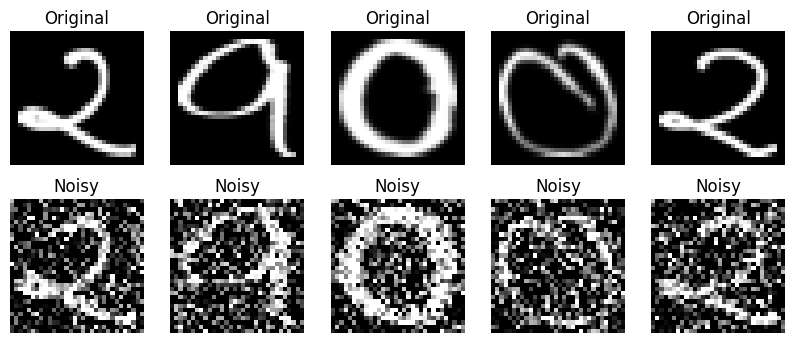

In [ ]:
samples_to_show = 5
plt.figure(figsize=(10, 4))

for idx in range(samples_to_show):
    # Clean image
    plt.subplot(2, samples_to_show, idx + 1)
    plt.imshow(x_train[idx].reshape(image_size, image_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Same image with noise
    plt.subplot(2, samples_to_show, idx + 1 + samples_to_show)
    plt.imshow(x_train_noisy[idx].reshape(image_size, image_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

## 6. Build convolutional autoencoder

Architecture:
- Encoder compresses noisy input into compact latent representation
- Decoder reconstructs clean image from latent features

**Why we do this:** encoder-decoder models are effective for denoising and representation learning.

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

model_input = Input(shape=(image_size, image_size, 1))

# Encoder
encoder = Conv2D(32, (3, 3), activation='relu', padding='same')(model_input)
encoder = MaxPooling2D((2, 2), padding='same')(encoder)

encoder = Conv2D(64, (3, 3), activation='relu', padding='same')(encoder)
encoder = MaxPooling2D((2, 2), padding='same')(encoder)

# Latent representation
latent = Conv2D(128, (3, 3), activation='relu', padding='same')(encoder)

# Decoder
decoder = Conv2D(128, (3, 3), activation='relu', padding='same')(latent)
decoder = UpSampling2D((2, 2))(decoder)

decoder = Conv2D(64, (3, 3), activation='relu', padding='same')(decoder)
decoder = UpSampling2D((2, 2))(decoder)

model_output = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(decoder)

autoencoder = Model(model_input, model_output)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the autoencoder

We train the model using noisy images as input and clean images as target.

**Why we do this:** this supervised reconstruction setup teaches the network to remove noise patterns while preserving digit structure.

In [9]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - loss: 0.2769 - val_loss: 0.1834
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - loss: 0.1722 - val_loss: 0.1641
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - loss: 0.1612 - val_loss: 0.1575
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - loss: 0.1558 - val_loss: 0.1541
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - loss: 0.1528 - val_loss: 0.1529
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - loss: 0.1502 - val_loss: 0.1498
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - loss: 0.1494 - val_loss: 0.1505
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - loss: 0.1471 - val_loss: 0.1468
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - loss: 0.1461 - val_loss: 0.1467
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - loss: 0.1452 - val_loss: 0.1455


## 8. Plot training and validation loss

We plot loss curves to monitor learning progress and generalization.

**Why we do this:** diverging train/validation loss can indicate overfitting or unstable training.

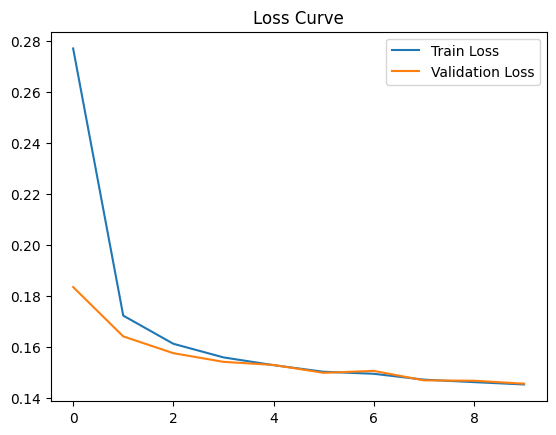

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## 9. Predict denoised images

We pass noisy test images through the trained autoencoder.

**Why we do this:** this is the final inference stage to evaluate practical denoising quality.

In [11]:
denoised_images = autoencoder.predict(x_test_noisy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


## 10. Visualize noisy, denoised, and original images

We compare three rows: noisy input, denoised output, and original ground truth.

**Why we do this:** side-by-side comparison is the most intuitive way to assess reconstruction quality.

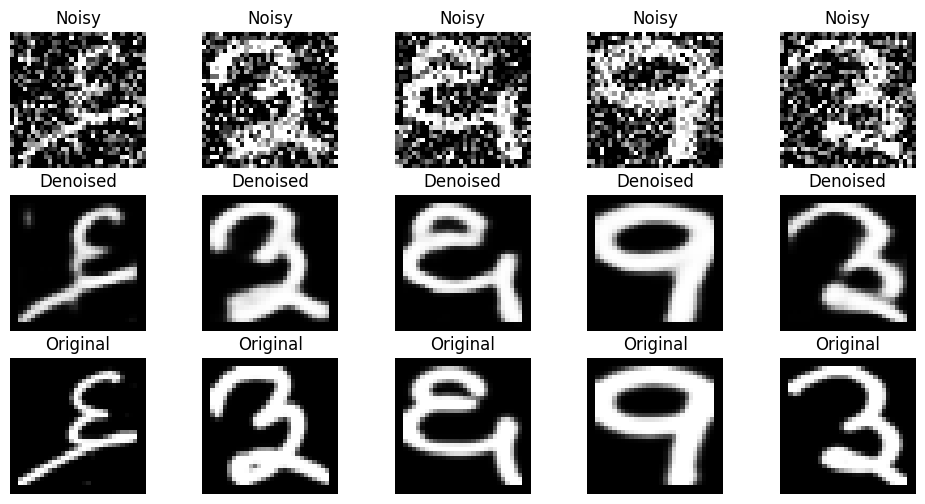

In [ ]:
samples_to_show = 5
plt.figure(figsize=(12, 6))

for idx in range(samples_to_show):
    # Noisy input
    plt.subplot(3, samples_to_show, idx + 1)
    plt.imshow(x_test_noisy[idx].reshape(image_size, image_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Model output
    plt.subplot(3, samples_to_show, idx + 1 + samples_to_show)
    plt.imshow(denoised_images[idx].reshape(image_size, image_size), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Ground truth
    plt.subplot(3, samples_to_show, idx + 1 + 2 * samples_to_show)
    plt.imshow(x_test[idx].reshape(image_size, image_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()